# [문제] bmi.csv 데이터 파일을 사용하여 아래 문제를 구현하는 코드를 작성하시오.

제출 파일명: 홍길동_0504.ipynb (구글드라이브와 클래스룸 두곳에 모두 업로드 할것!!)

<공통 처리 조건>
- 상위 데이터 100개중 height와 weight를 사용해서 클러스터링 데이터로 사용할것
- K-means clustering으로 구현한 다음  AgglomerativeClustering으로 구현하는 코드를 작성 할 것.

(1) K-means clustering으로 구현하는 코드를 작성하시오.
(2) AgglomerativeClustering으로 구현하는 코드를 작성하시오.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('bmi.csv')
df.head(10)

,height,weight,label
0,142,62,fat
1,142,73,fat
2,177,61,normal
3,187,48,thin
4,153,60,fat
5,186,59,thin
6,166,53,normal
7,193,56,thin
8,184,43,thin
9,193,64,thin


# (1) K-means clustering으로 구현하는 코드를 작성하시오.

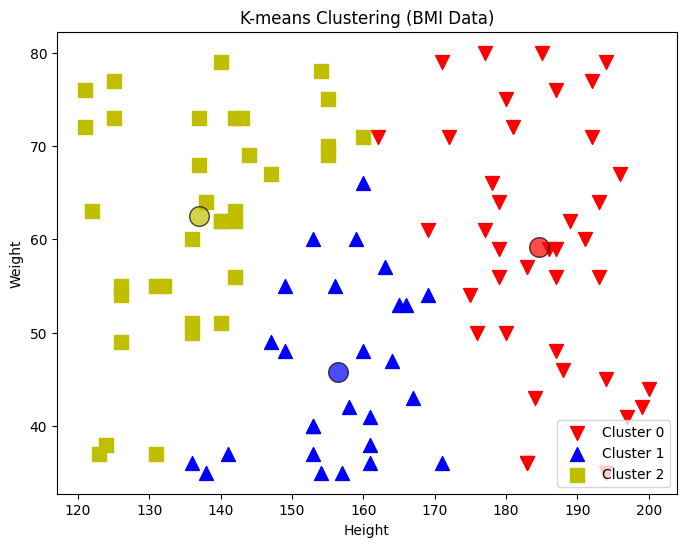

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_df = df.loc[:100, ['height', 'weight']]
X = X_df.values  

model = KMeans(n_clusters=3, init="random", n_init=10, random_state=42)
model.fit(X)
labels = model.labels_
centers = model.cluster_centers_

# 시각화 구현
plt.figure(figsize=(8, 6))

plt.scatter(X[labels == 0, 0], X[labels == 0, 1], s=100, marker='v', c='r', label='Cluster 0')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], s=100, marker='^', c='b', label='Cluster 1')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], s=100, marker='s', c='y', label='Cluster 2')

plt.scatter(centers[0, 0], centers[0, 1], s=200, c='r', edgecolors='black', alpha=0.7)
plt.scatter(centers[1, 0], centers[1, 1], s=200, c='b', edgecolors='black', alpha=0.7)
plt.scatter(centers[2, 0], centers[2, 1], s=200, c='y', edgecolors='black', alpha=0.7)

plt.title('K-means Clustering (BMI Data)')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

# (2) AgglomerativeClustering으로 구현하는 코드를 작성하시오.

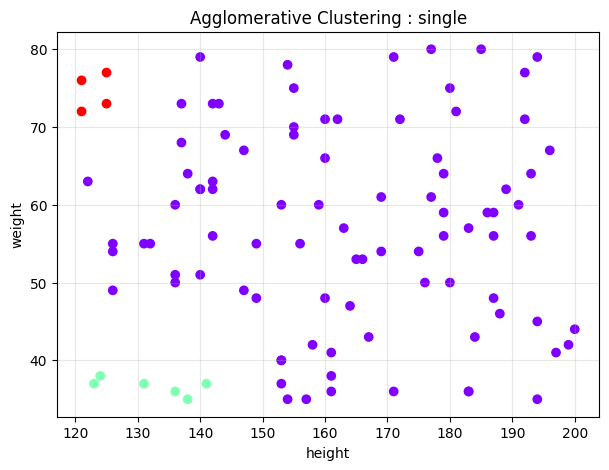

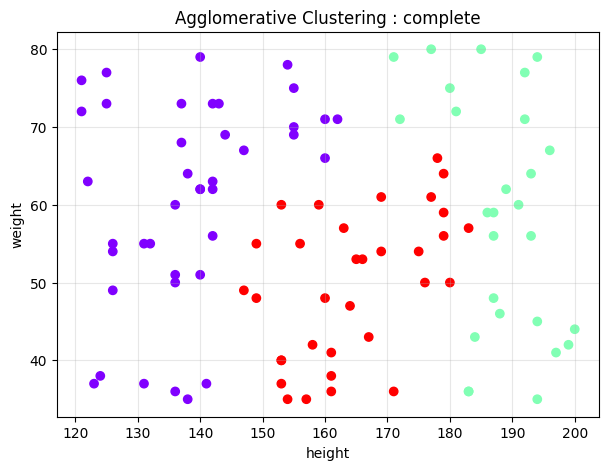

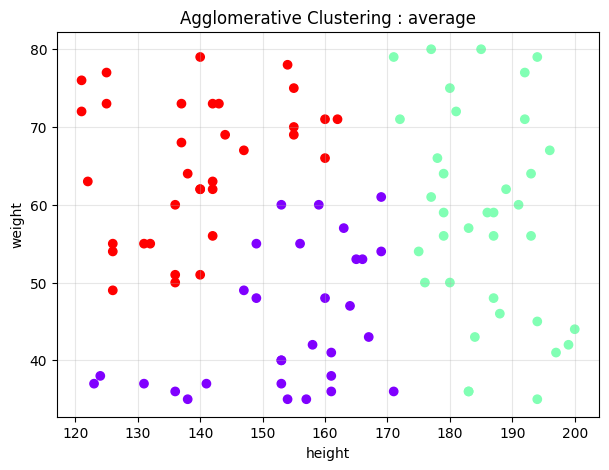

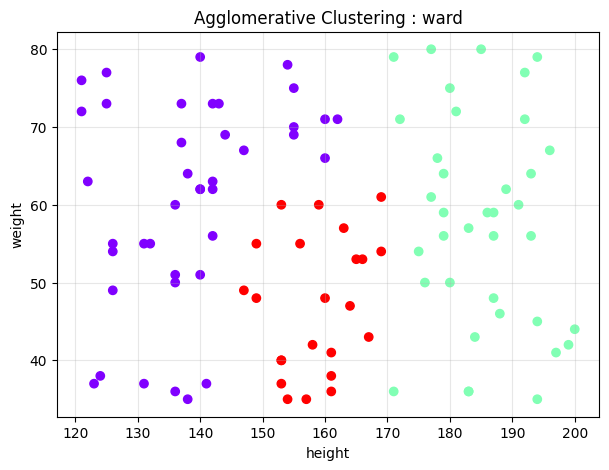

In [4]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X = df.iloc[:100, :2] 

linkage_list = ['single', 'complete', 'average', 'ward']

# 클러스터링 및 시각화
for idx, method in enumerate(linkage_list):
    plt.figure(idx, figsize=(7, 5))
    
    hier = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=method)
    hier.fit(X)
    
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=hier.labels_, cmap='rainbow')
    
    plt.title('Agglomerative Clustering : ' + method)
    plt.xlabel('height')
    plt.ylabel('weight')
    plt.grid(True, alpha=0.3)

plt.show()